# 物体検出（Faster R-CNN / SSD, PyTorch）

このノートブックでは、PyTorchの学習済みモデルを用いてFaster R-CNNとSSDを動かし、推論結果を比較します。

In [1]:
# 必要なライブラリ
import os
import random
import numpy as np
import torch
from torchvision import transforms
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image

# 日本語フォント設定（利用可能なものを自動選択）
def set_japanese_font():
    candidates = [
        "IPAexGothic",
        "IPAGothic",
        "Noto Sans CJK JP",
        "Noto Sans JP",
        "TakaoGothic",
        "Yu Gothic",
        "Hiragino Sans",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_japanese_font()

# 再現性
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# デバイス
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. テスト画像の読み込み

同じフォルダにあるtest.jpgを使用します。自分の画像に置き換えても構いません。

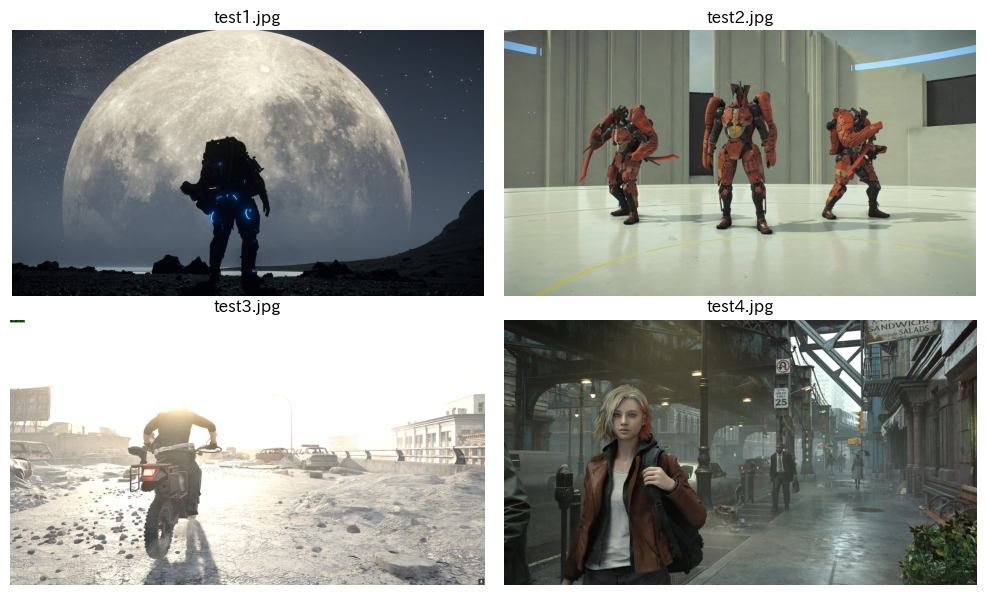

In [6]:
img_paths = [f"test{i}.jpg" for i in range(1, 5)]
for p in img_paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"{p} が見つかりません")

pil_imgs = [Image.open(p).convert("RGB") for p in img_paths]

plt.figure(figsize=(10, 6))
for i, (p, img) in enumerate(zip(img_paths, pil_imgs)):
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.axis("off")
    ax.set_title(p)
plt.tight_layout()
plt.show()

## 2. Faster R-CNNの推論

COCOで学習済みのFaster R-CNNを使って推論し、検出結果を表示します。

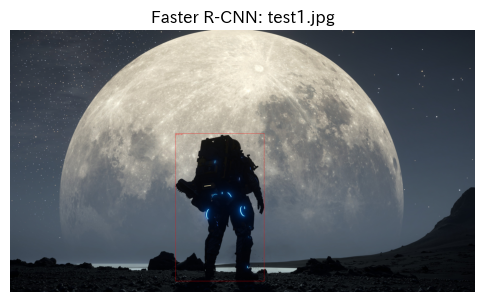

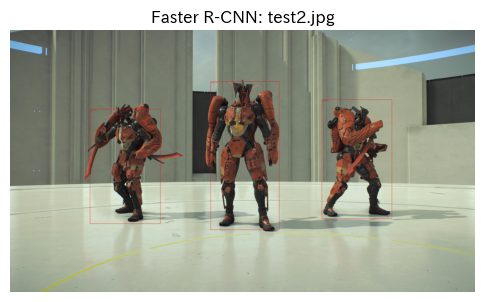

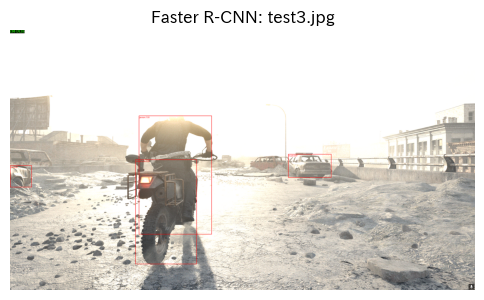

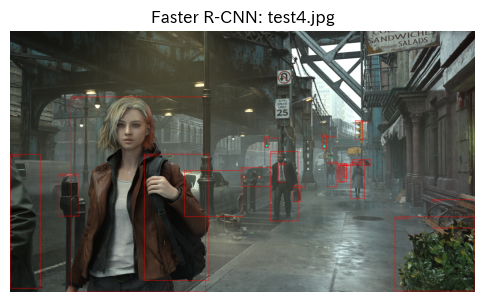

In [7]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights_fr = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model_fr = fasterrcnn_resnet50_fpn(weights=weights_fr).to(device)
model_fr.eval()

score_thresh = 0.7

for p, img in zip(img_paths, pil_imgs):
    img_tensor = weights_fr.transforms()(img).to(device)

    with torch.no_grad():
        outputs = model_fr([img_tensor])[0]

    keep = outputs["scores"] >= score_thresh
    boxes = outputs["boxes"][keep]
    labels = outputs["labels"][keep]
    scores = outputs["scores"][keep]

    img_uint8 = (img_tensor * 255).byte()
    label_names = [weights_fr.meta["categories"][i] for i in labels.cpu().tolist()]

    boxed = draw_bounding_boxes(
        img_uint8.cpu(),
        boxes=boxes.cpu(),
        labels=[f"{n}:{s:.2f}" for n, s in zip(label_names, scores.cpu().tolist())],
        colors="red",
        width=2,
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(boxed.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"Faster R-CNN: {p}")
    plt.show()

## 3. SSDの推論

COCOで学習済みのSSDを使って推論し、検出結果を表示します。

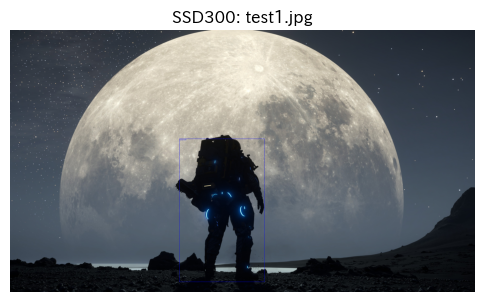

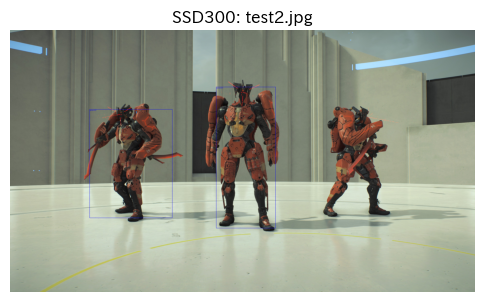

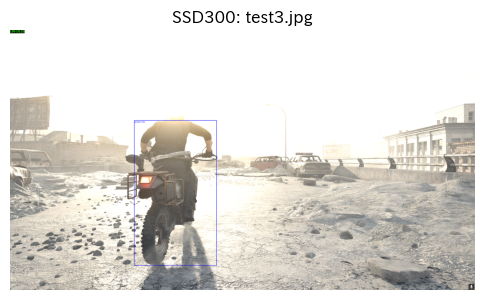

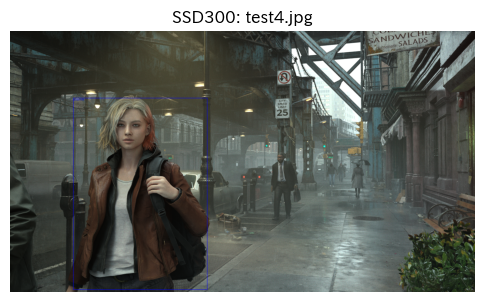

In [8]:
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights

weights_ssd = SSD300_VGG16_Weights.DEFAULT
model_ssd = ssd300_vgg16(weights=weights_ssd).to(device)
model_ssd.eval()

score_thresh_ssd = 0.5

for p, img in zip(img_paths, pil_imgs):
    img_tensor_ssd = weights_ssd.transforms()(img).to(device)

    with torch.no_grad():
        outputs_ssd = model_ssd([img_tensor_ssd])[0]

    keep_ssd = outputs_ssd["scores"] >= score_thresh_ssd
    boxes_ssd = outputs_ssd["boxes"][keep_ssd]
    labels_ssd = outputs_ssd["labels"][keep_ssd]
    scores_ssd = outputs_ssd["scores"][keep_ssd]

    img_uint8_ssd = (img_tensor_ssd * 255).byte()
    label_names_ssd = [weights_ssd.meta["categories"][i] for i in labels_ssd.cpu().tolist()]

    boxed_ssd = draw_bounding_boxes(
        img_uint8_ssd.cpu(),
        boxes=boxes_ssd.cpu(),
        labels=[f"{n}:{s:.2f}" for n, s in zip(label_names_ssd, scores_ssd.cpu().tolist())],
        colors="blue",
        width=2,
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(boxed_ssd.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"SSD300: {p}")
    plt.show()